# 4 — Early Predictors of a Top-15% Customer

Idea #4 from the "5 ideas to further investigate" list: can a future top-15%-by-spend customer be flagged from first-order and first-90-day behavior, rather than only identified in hindsight? This notebook pulls out just that question — the standalone deep-dive on who the top 15% *are* (retrospectively) lives in [`0.8.1_deepdive_top15pct.ipynb`](0.8.1_deepdive_top15pct.ipynb), section 4 of which this is extracted from.

## Load & prep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]
POS, NEG = '#2a78d6', '#e34948'
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False, y_grid=True):
    if x_grid: ax.grid(axis='x', zorder=0)
    if y_grid: ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

def dollars(v, _):
    return f'${v:,.0f}'

DATA_DIR = '.'

In [2]:
df = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['month'] = df['order date (DateOrders)'].dt.to_period('M')
clean = df[df['order date (DateOrders)'] < '2017-10-01'].copy()

order_level = clean.drop_duplicates('Order Id').set_index('Order Id')
profit_by_cust = order_level.groupby('Order Customer Id')['Order Profit Per Order'].sum()

cust = clean.groupby('Order Customer Id').agg(
    n_orders=('Order Id', 'nunique'),
    total_spend=('Order Item Total', 'sum'),
    avg_discount_rate=('Order Item Discount Rate', 'mean'),
    late_risk_rate=('Late_delivery_risk', 'mean'),
    segment=('Customer Segment', lambda s: s.mode()[0]),
    market=('Market', lambda s: s.mode()[0]),
    region=('Order Region', lambda s: s.mode()[0]),
    first_order=('order date (DateOrders)', 'min'),
    last_order=('order date (DateOrders)', 'max'),
).reset_index()
cust['total_profit'] = cust['Order Customer Id'].map(profit_by_cust)
cust['aov'] = cust['total_spend'] / cust['n_orders']
cust['tenure_days'] = (cust['last_order'] - cust['first_order']).dt.days
END = clean['order date (DateOrders)'].max()
cust['recency_days'] = (END - cust['last_order']).dt.days

cust = cust.sort_values('total_spend', ascending=False).reset_index(drop=True)
N15 = int(np.ceil(len(cust) * 0.15))
cust['grp'] = ['Top 15%'] * N15 + ['Rest 85%'] * (len(cust) - N15)
top15_ids = set(cust.loc[cust['grp'] == 'Top 15%', 'Order Customer Id'])
clean['grp'] = np.where(clean['Order Customer Id'].isin(top15_ids), 'Top 15%', 'Rest 85%')

threshold = cust.loc[cust['grp'] == 'Top 15%', 'total_spend'].min()
print(f"{N15:,} customers qualify (spend >= ${threshold:,.0f} over the window)")

1,850 customers qualify (spend >= $3,865 over the window)


## 4. Early predictors — can we flag a future top-15% customer from their first 90 days?

Everything above is retrospective — it describes who top-15% customers turn out to be, using their *entire* spend history. That's not actionable at the point you'd actually want to act: right after someone's first order. This section asks whether first-order and first-90-day behavior — order size, category, and how fast they come back — carries enough signal to flag them early.

To keep the 90-day window uncensored (not cut off by the Oct 2017 artifact boundary), this restricts to customers whose first order was on or before `2017-10-01 minus 90 days`. That excludes only 62 of 12,330 customers (0.5%) — negligible cohort bias, unlike the eligibility filters elsewhere in this archive that meaningfully shrink the population.

In [3]:
WINDOW = 90
RUNWAY_CUTOFF = pd.Timestamp('2017-10-01') - pd.Timedelta(days=WINDOW)

order_totals = clean.groupby('Order Id').agg(
    customer=('Order Customer Id', 'first'),
    order_date=('order date (DateOrders)', 'first'),
    order_value=('Order Item Total', 'sum'),
    top_category=('Category Name', lambda s: s.mode()[0]),
).reset_index()
order_totals = order_totals.sort_values(['customer', 'order_date'])
order_totals['seq'] = order_totals.groupby('customer').cumcount() + 1

first_orders = order_totals[order_totals['seq'] == 1].set_index('customer')
second_orders = order_totals[order_totals['seq'] == 2].set_index('customer')

early = cust.set_index('Order Customer Id')[['grp']].copy()
early['is_top15'] = early['grp'] == 'Top 15%'
early['first_order_date'] = first_orders['order_date']
early['first_order_value'] = first_orders['order_value']
early['first_order_category'] = first_orders['top_category']
early['days_to_2nd_order'] = (second_orders['order_date'] - first_orders['order_date']).dt.days
eligible = early['first_order_date'] <= RUNWAY_CUTOFF

merged = order_totals.merge(early[['first_order_date']], left_on='customer', right_index=True)
merged['days_since_first'] = (merged['order_date'] - merged['first_order_date']).dt.days
w = merged[(merged['days_since_first'] >= 0) & (merged['days_since_first'] <= WINDOW)]
agg90 = w.groupby('customer').agg(n_orders_90d=('Order Id', 'nunique'), spend_90d=('order_value', 'sum'))
early = early.join(agg90)
early['reordered_within_90d'] = (early['days_to_2nd_order'] <= WINDOW).fillna(False)

early = early[eligible].copy()
print(f"{len(early):,} customers with a full 90-day runway before the data break "
      f"({eligible.sum() / len(eligible) * 100:.1f}% of the base) -- top-15% rate {early['is_top15'].mean()*100:.1f}%, matches overall")

12,268 customers with a full 90-day runway before the data break (99.5% of the base) -- top-15% rate 15.1%, matches overall


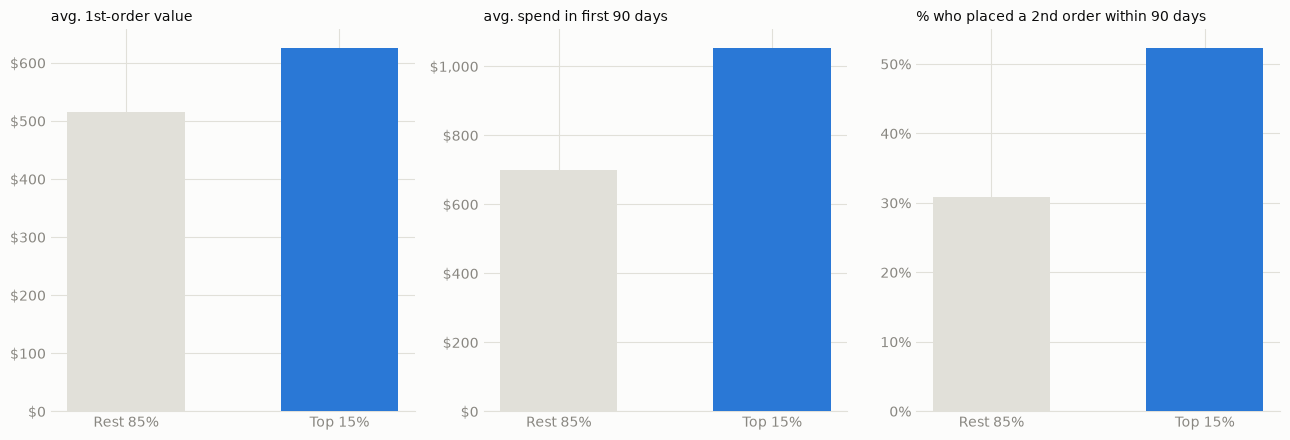

          first_order_value  spend_90d  n_orders_90d  reorder_rate_90d
is_top15                                                              
False               514.740    700.291         1.368             0.309
True                626.191   1054.188         1.694             0.524
corr(first_order_value, is_top15) = +0.132
corr(spend_90d, is_top15) = +0.256
corr(n_orders_90d, is_top15) = +0.180
corr(reordered_within_90d, is_top15) = +0.162


In [4]:
grp_means = early.groupby('is_top15').agg(
    first_order_value=('first_order_value', 'mean'),
    spend_90d=('spend_90d', 'mean'),
    n_orders_90d=('n_orders_90d', 'mean'),
    reorder_rate_90d=('reordered_within_90d', 'mean'),
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
panels = [
    ('first_order_value', 'avg. 1st-order value'),
    ('spend_90d', 'avg. spend in first 90 days'),
    ('reorder_rate_90d', '% who placed a 2nd order within 90 days'),
]
for ax, (col, title) in zip(axes, panels):
    vals = grp_means[col]
    colors = [GRID, BLUE]
    bars = ax.bar(['Rest 85%', 'Top 15%'], vals.reindex([False, True]), color=colors, width=0.55, zorder=3)
    if col == 'reorder_rate_90d':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollars))
    ax.set_title(title, loc='left', color=INK, fontsize=10)
    style_axis(ax, x_grid=False)
plt.tight_layout()
plt.show()

print(grp_means.round(3))
y = early['is_top15'].astype(int)
for col in ['first_order_value', 'spend_90d', 'n_orders_90d', 'reordered_within_90d']:
    print(f"corr({col}, is_top15) = {y.corr(early[col].astype(float)):+.3f}")

First-order size alone is a weak signal (\$626 vs \$515, corr +0.13) — a customer's very first basket barely moves the needle. **90-day spend is the strongest of the three** (corr +0.26, roughly double first-order value alone) because it captures repeat behavior, not just one basket. **Reordering within 90 days is the sharpest split**: 52.4% of eventual top-15% customers place a 2nd order in that window, vs. 30.9% of everyone else — a 21-point gap on a binary, easy-to-compute flag.

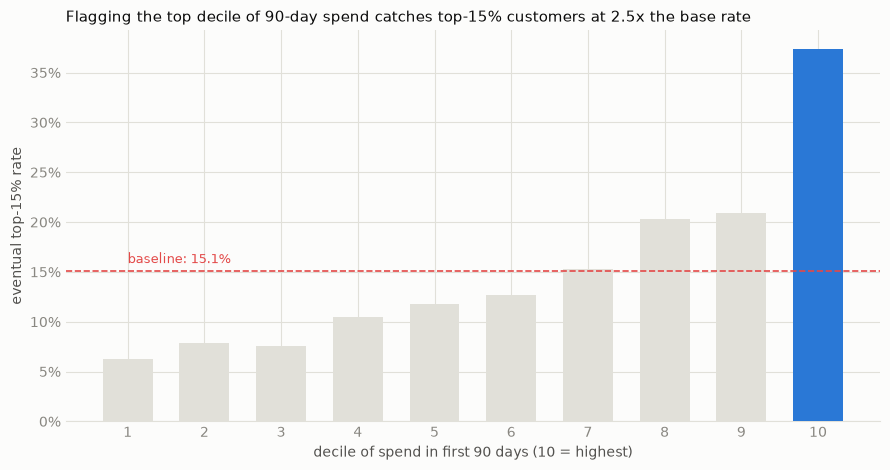

                   rate     n  capture_share
spend_90d_decile                            
1                 0.063  1227          0.042
2                 0.079  1227          0.052
3                 0.076  1227          0.050
4                 0.105  1226          0.070
5                 0.118  1227          0.078
6                 0.127  1227          0.084
7                 0.153  1226          0.102
8                 0.203  1227          0.135
9                 0.209  1227          0.139
10                0.374  1227          0.248
top decile alone captures 24.8% of all eventual top-15% customers


In [5]:
early['spend_90d_decile'] = pd.qcut(early['spend_90d'].rank(method='first'), 10, labels=False) + 1
lift = early.groupby('spend_90d_decile')['is_top15'].agg(rate='mean', n='count')
lift['capture_share'] = early.groupby('spend_90d_decile')['is_top15'].sum() / early['is_top15'].sum()
baseline = early['is_top15'].mean()

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(lift.index.astype(str), lift['rate'], color=[BLUE if d == 10 else GRID for d in lift.index], width=0.65, zorder=3)
ax.axhline(baseline, color=NEG, linewidth=1.2, linestyle='--', zorder=4)
ax.text(0, baseline + 0.008, f'baseline: {baseline*100:.1f}%', color=NEG, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
ax.set_xlabel('decile of spend in first 90 days (10 = highest)')
ax.set_ylabel('eventual top-15% rate')
ax.set_title('Flagging the top decile of 90-day spend catches top-15% customers at 2.5x the base rate', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=False)
plt.tight_layout()
plt.show()

print(lift.round(3))
print(f"top decile alone captures {lift.loc[10, 'capture_share']*100:.1f}% of all eventual top-15% customers")

In [6]:
early['spend_90d_half'] = np.where(early['spend_90d'] >= early['spend_90d'].median(),
                                    'Above-median 90d spend', 'Below-median 90d spend')
combo = early.groupby(['spend_90d_half', 'reordered_within_90d'])['is_top15'].agg(rate='mean', n='count')
combo['lift_vs_baseline'] = combo['rate'] / baseline
print(combo.round(3))

                                              rate     n  lift_vs_baseline
spend_90d_half         reordered_within_90d                               
Above-median 90d spend False                 0.155  2627             1.027
                       True                  0.257  3507             1.706
Below-median 90d spend False                 0.087  5456             0.576
                       True                  0.099   678             0.655


**The two signals compound, but reordering alone doesn't carry much on its own.** Customers who are *both* above-median on 90-day spend *and* reorder within 90 days hit a 25.7% top-15% rate — 1.7x baseline. Drop the spend condition and reordering barely helps (9.9% vs. 8.7% for no-reorder, both *below* baseline) — so the useful rule is "spend meaningfully in the first 90 days," and reordering quickly is a multiplier on top of that, not an independent flag.

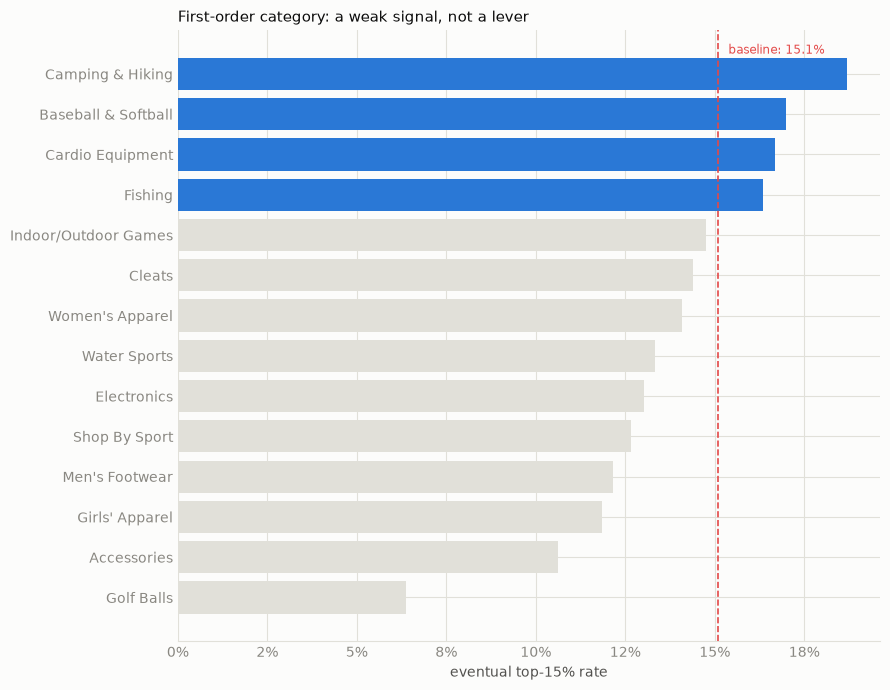

                       rate     n
first_order_category             
Camping & Hiking      0.187  1943
Baseball & Softball   0.170   106
Cardio Equipment      0.167  1517
Fishing               0.163  1224
Indoor/Outdoor Games  0.148  1097
Cleats                0.144  2460
Women's Apparel       0.141   831
Water Sports          0.133   578
Electronics           0.130   269
Shop By Sport         0.127   371
Men's Footwear        0.122  1151
Girls' Apparel        0.118    76
Accessories           0.106   311
Golf Balls            0.064    94


In [7]:
cat = early.groupby('first_order_category')['is_top15'].agg(rate='mean', n='count')
cat = cat[cat['n'] >= 50].sort_values('rate', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
colors = [BLUE if r >= baseline else GRID for r in cat['rate']]
ax.barh(cat.index[::-1], cat['rate'][::-1], color=colors[::-1], zorder=3)
ax.axvline(baseline, color=NEG, linewidth=1.2, linestyle='--', zorder=4)
ax.text(baseline + 0.003, len(cat) - 0.5, f'baseline: {baseline*100:.1f}%', color=NEG, fontsize=8.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
ax.set_xlabel('eventual top-15% rate')
ax.set_title('First-order category: a weak signal, not a lever', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=False, y_grid=False)
plt.tight_layout()
plt.show()

print(cat.round(3))

Category of the first order is the weakest of the three candidate signals — a range of only 6.4% (Golf Balls) to 18.7% (Camping & Hiking) around a 15.1% baseline, with several categories sitting right on top of the baseline. There's a mild lean toward outdoor/gear categories over apparel/accessories, but nothing sharp enough to build a targeting rule on, and the smaller categories here are thin samples. Not worth operationalizing on its own.

**Section takeaway:** first-order size is a poor early flag; 90-day spend and a 90-day reorder are decent ones, and best used together. A simple operational rule — "flag any customer whose spend in their first 90 days lands in the top decile, and watch especially closely if they've already placed a 2nd order" — would catch about a quarter of eventual top-15% customers at roughly 2.5x the base rate, using only data available 90 days after acquisition. First-order category isn't worth building into that rule. None of these signals is strong enough to be a precise classifier (this is a lift tool for prioritization, not a high-confidence label) — consistent with the rest of this notebook's finding that top-15% membership is driven by sustained activity level, not a trait visible in a single early transaction.